# Imports

In [1]:
import numpy as np
import pandas as pd

import sklearn as sk
from sklearn import base
from sklearn import calibration
from sklearn import cluster
from sklearn import compose
from sklearn import covariance
from sklearn import cross_decomposition
from sklearn import datasets
from sklearn import decomposition
from sklearn import discriminant_analysis
from sklearn import dummy
from sklearn import ensemble
from sklearn import exceptions
from sklearn import experimental
from sklearn import feature_extraction
from sklearn import feature_selection
from sklearn import gaussian_process
from sklearn import impute
from sklearn import inspection
from sklearn import isotonic
from sklearn import kernel_approximation
from sklearn import kernel_ridge
from sklearn import linear_model
from sklearn import manifold
from sklearn import metrics
from sklearn import mixture
from sklearn import model_selection
from sklearn import multiclass
from sklearn import multioutput
from sklearn import naive_bayes
from sklearn import neighbors
from sklearn import neural_network
from sklearn import pipeline
from sklearn import preprocessing
from sklearn import random_projection
from sklearn import semi_supervised
from sklearn import svm
from sklearn import tree
from sklearn import utils

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Analisi
1. Quante sono le istanze contenute nel dataset? _____ Il dataset è completo (cioè per ogni
istanza tutti i valori di ogni attributo sono sempre correttamente specificati – non esistono
“missing values”)? _____ Il dataset è bilanciato per quanto riguarda la classe da predire? ______
(punti 1).
2. Considerare la feature battery_power e rappresentare con un istogramma la distribuzione
dei valori. Raggruppare poi i valori secondo questa suddivisione: gruppo1 501-800; gruppo2
801-1200; gruppo3 1201-1600; gruppo4 1601-1998, visualizzare la distribuzione nei gruppi.
Indicare per ogni gruppo il numero di istanze per ogni range di prezzo. (punti 3)
3. Considerare solo i cellulari che hanno il 4G e una RAM superiore (>) a 2 GB (2048 MB).
Rappresentare in uno scatterplot i valori di ram (ascisse) e memoria interna (ordinate). Colorare
i punti nel grafico in base al valore della colonna price_range. Usare i nomi dei due attributi
come etichette dell’asse delle ascisse e dell’asse delle ordinate. (punti 4)
4. Realizzare una tabella pivot in cui rappresentare il numero di cellulari per ogni range di
prezzo (variabile sulle colonne) considerando sulle righe le variabili touch_screen e
int_memory (suddivisa in 5 gruppi). (punti 2)

## Es. 0

In [2]:
df = pd.read_csv('dataset.csv', sep=',')
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


## Es.1 

In [3]:
print('Rows (instances):', df.shape[0])

Rows (instances): 2000


In [4]:
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

Nessun missing value.

In [5]:
df['price_range'].value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

Dataset è bilanciato rispetto alla classe da predire.

## Es. 2

<Axes: ylabel='Frequency'>

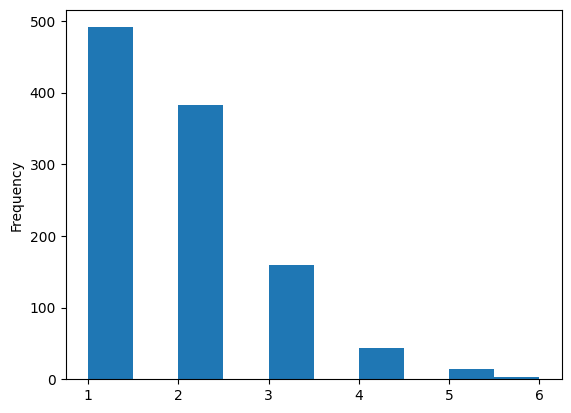

In [6]:
df['battery_power'].value_counts().plot(kind='hist')

In [7]:
bins = [500, 800, 1200, 1600, 1998]
group_names = ['gruppo1', 'gruppo2', 'gruppo3', 'gruppo4']

df['battery_power_cut'] = pd.cut(df['battery_power'], bins, labels=group_names)
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range,battery_power_cut
0,842,0,2.2,0,1,0,7,0.6,188,2,...,756,2549,9,7,19,0,0,1,1,gruppo2
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,1988,2631,17,3,7,1,1,0,2,gruppo2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1716,2603,11,2,9,1,1,0,2,gruppo1
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1786,2769,16,8,11,1,0,0,2,gruppo1
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1212,1411,8,2,15,1,1,0,1,gruppo4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1890,668,13,4,19,1,1,0,0,gruppo1
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,1965,2032,11,10,16,1,1,1,2,gruppo4
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,1632,3057,9,1,5,1,1,0,3,gruppo4
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,670,869,18,10,19,1,1,1,0,gruppo3


In [8]:
df['battery_power_cut'].value_counts()

battery_power_cut
gruppo2    545
gruppo4    519
gruppo3    514
gruppo1    422
Name: count, dtype: int64

In [9]:
df[['battery_power_cut', 'price_range']].value_counts()

battery_power_cut  price_range
gruppo4            3              177
gruppo2            0              167
gruppo3            3              151
gruppo2            1              142
gruppo1            0              137
gruppo4            2              135
gruppo3            1              127
gruppo4            1              124
gruppo3            2              123
gruppo2            2              122
gruppo1            2              120
gruppo2            3              114
gruppo3            0              113
gruppo1            1              107
gruppo4            0               83
gruppo1            3               58
Name: count, dtype: int64

## Es. 3

In [10]:
filtered_df = df[(df['four_g'] == 1) & (df['ram'] > 2048)]
filtered_df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range,battery_power_cut
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,1988,2631,17,3,7,1,1,0,2,gruppo2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1716,2603,11,2,9,1,1,0,2,gruppo1
6,1821,0,1.7,0,4,1,10,0.8,139,8,...,1018,3220,13,8,18,1,0,1,3,gruppo4
11,1520,1,2.2,0,5,1,33,0.5,177,8,...,1005,3826,14,9,13,1,1,1,3,gruppo3
16,838,0,0.5,0,1,1,13,0.1,196,8,...,1850,3554,10,9,19,1,0,1,3,gruppo2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1974,915,1,0.5,1,9,1,33,0.3,199,2,...,986,2156,7,3,13,1,1,0,1,gruppo2
1977,1379,0,1.1,1,1,1,18,0.2,129,2,...,885,2358,10,5,15,1,1,0,2,gruppo3
1991,1882,0,2.0,0,11,1,44,0.8,113,8,...,743,3579,19,8,20,1,1,0,3,gruppo4
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,1632,3057,9,1,5,1,1,0,3,gruppo4


Text(0, 0.5, 'int_memory')

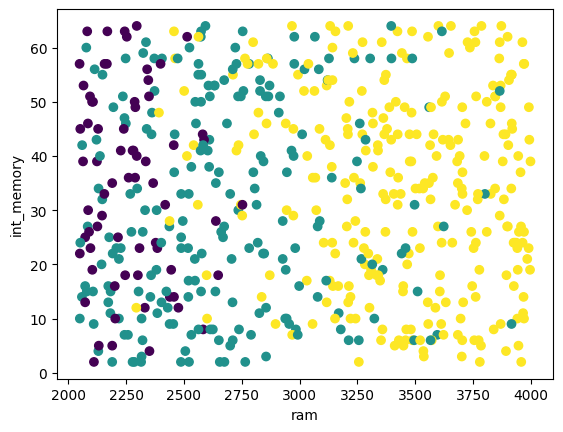

In [11]:
colours = filtered_df['price_range']

plt.scatter(filtered_df['ram'], filtered_df['int_memory'], c=colours)
plt.xlabel(filtered_df['ram'].name)
plt.ylabel(filtered_df['int_memory'].name)

## Es. 4

In [12]:
df['int_memory_cut'] = pd.cut(df['int_memory'], 5)

In [13]:
df.pivot_table('price_range', index=['touch_screen', 'int_memory_cut'], aggfunc='count')

/var/folders/ph/t7gwl3k17_l0cxktc3ll17600000gn/T/ipykernel_20898/1794368438.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table('price_range', index=['touch_screen', 'int_memory_cut'], aggfunc='count')


price_range
touch_screen int_memory_cut             
0            (1.938, 14.4]           210
             (14.4, 26.8]            192
             (26.8, 39.2]            208
             (39.2, 51.6]            185
             (51.6, 64.0]            199
1            (1.938, 14.4]           244
             (14.4, 26.8]            184
             (26.8, 39.2]            193
             (39.2, 51.6]            201
             (51.6, 64.0]            184